# 💸 Predicting Loan Payback     ................................................................................................................................................
> # 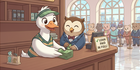 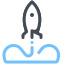 
>  **Predict sales prices and practice feature engineering, RFs, and gradient boosting**                 
## Author: RIDDY MAZUMDER 
## 🔗 Connect with Me
> [![Kaggle](https://img.shields.io/badge/Kaggle-20BEFF?style=for-the-badge&logo=kaggle&logoColor=white)](https://www.kaggle.com/riddymazumder)
> [![GitHub](https://img.shields.io/badge/GitHub-181717?style=for-the-badge&logo=github&logoColor=white)](https://github.com/RiddyMazumder)
> [![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/riddy-mazumder-7bab46338/)
> [![Gmail](https://img.shields.io/badge/Gmail-D14836?style=for-the-badge&logo=gmail&logoColor=white)](mailto:riddymazumder1971@gmail.com)

## Description 
**This notebook follows a complete end-to-end data science workflow, from loading data to model evaluation and final submission.**  
****Each section is clearly explained and well-structured for learning and presentation.****
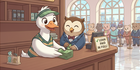
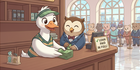
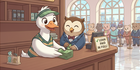
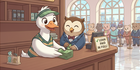
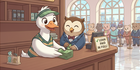
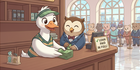
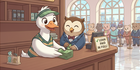

## 1. Libraries Required

****In this section, we import all the necessary Python libraries used throughout the project.****  
**These include libraries for**:
- **Data manipulation**  
- **Visualization**
- **Data Preprocessing**
- **Machine learning**

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


## 2. Load Dataset

In [13]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')

df_train['dataset'] = 'train'
df_test['dataset'] = 'test'
df_test['loan_paid_back'] = np.nan  # placeholder for unknown labels

df = pd.concat([df_train, df_test], ignore_index=True, sort=False)


In [4]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## 3. Data Exploration & Cleaning

## 3.1 Overview

**Check shape, missing values, data types.**

In [25]:
df.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,848563.000000,848563.000000,848563.000000,848563.000000,848563.000000,848563.000000,593994.000000
mean,424281.000000,48218.466144,0.120662,680.952514,15019.234385,12.355139,0.798820
std,244959.182573,26714.243232,0.068576,55.484775,6925.217352,2.011555,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.050000,3.200000,0.000000
25%,212140.500000,27939.785000,0.072000,646.000000,10275.010000,10.990000,1.000000
50%,424281.000000,46552.600000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,636421.500000,61003.900000,0.156000,719.000000,18851.520000,13.680000,1.000000
max,848562.000000,393381.740000,0.627000,849.000000,48959.950000,21.290000,1.000000


In [12]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,dataset
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,train
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,train
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,train
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,train
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,train


In [26]:
df['dataset'].value_counts()


dataset
train    593994
test     254569
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848563 entries, 0 to 848562
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    848563 non-null  int64  
 1   annual_income         848563 non-null  float64
 2   debt_to_income_ratio  848563 non-null  float64
 3   credit_score          848563 non-null  int64  
 4   loan_amount           848563 non-null  float64
 5   interest_rate         848563 non-null  float64
 6   gender                848563 non-null  object 
 7   marital_status        848563 non-null  object 
 8   education_level       848563 non-null  object 
 9   employment_status     848563 non-null  object 
 10  loan_purpose          848563 non-null  object 
 11  grade_subgrade        848563 non-null  object 
 12  loan_paid_back        593994 non-null  float64
 13  dataset               848563 non-null  object 
dtypes: float64(5), int64(2), object(7)
memory usage: 90.

## 3.2 Visualization

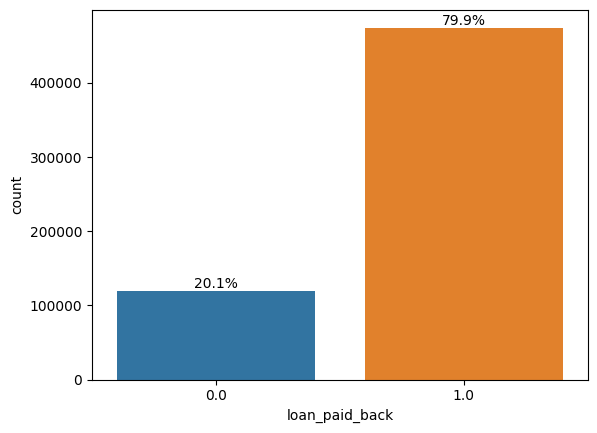

loan_paid_back
1.0    79.9
0.0    20.1
Name: proportion, dtype: float64


In [40]:
#!pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt
train = df[df['dataset']=='train']
vc = train['loan_paid_back'].value_counts(normalize=True) * 100

ax = sns.countplot(x='loan_paid_back', data=train)

# map each bar to the actual category shown on the x-axis
labels = [float(t.get_text()) for t in ax.get_xticklabels()]
for p, lab in zip(ax.patches, labels):
    ax.text(p.get_x()+p.get_width()/2., p.get_height(), f'{vc.loc[lab]:.1f}%', ha='center', va='bottom')

plt.show()
print(vc.round(1))



In [28]:
categorical_cols = ['gender','marital_status','education_level','employment_status','loan_purpose','grade_subgrade']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")


--- gender ---
gender
Female    437655
Male      405538
Other       5370
Name: count, dtype: int64


--- marital_status ---
marital_status
Single      412529
Married     396239
Divorced     30434
Widowed       9361
Name: count, dtype: int64


--- education_level ---
education_level
Bachelor's     399530
High School    262279
Master's       132923
Other           38002
PhD             15829
Name: count, dtype: int64


--- employment_status ---
employment_status
Employed         643852
Unemployed        89200
Self-employed     75023
Retired           23513
Student           16975
Name: count, dtype: int64


--- loan_purpose ---
loan_purpose
Debt consolidation    463658
Other                  91589
Car                    82997
Home                   63102
Education              52360
Business               50379
Medical                32424
Vacation               12054
Name: count, dtype: int64


--- grade_subgrade ---
grade_subgrade
C3    84105
C4    79669
C2    77777
C1    76177
C5    7

In [42]:
df[categorical_cols].nunique()

gender                3
marital_status        4
education_level       5
employment_status     5
loan_purpose          8
grade_subgrade       30
dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


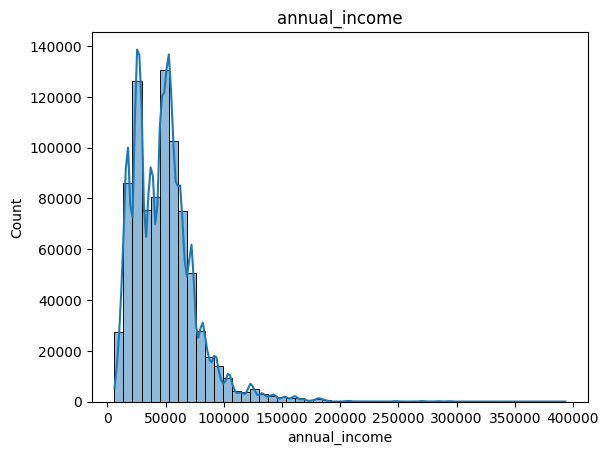

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


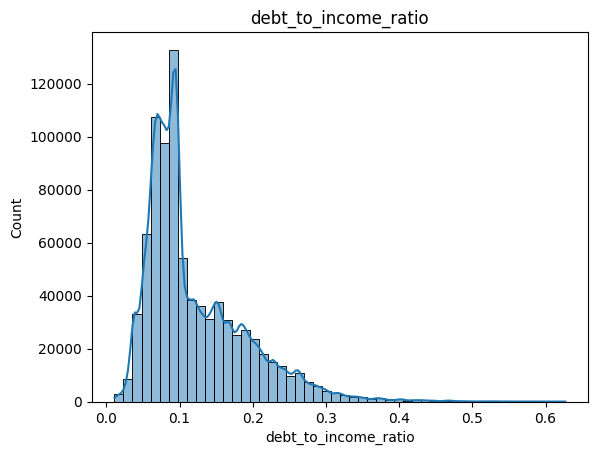

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


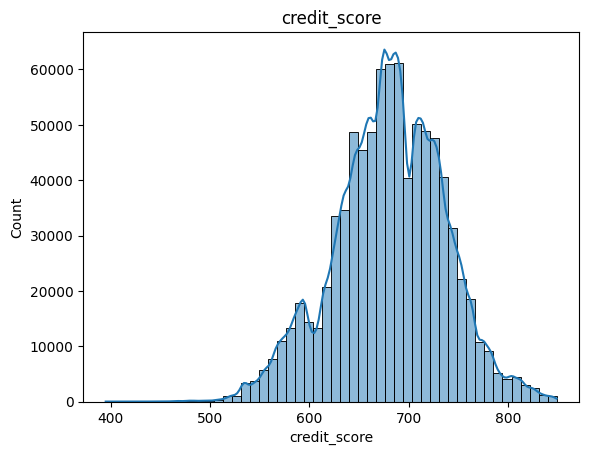

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


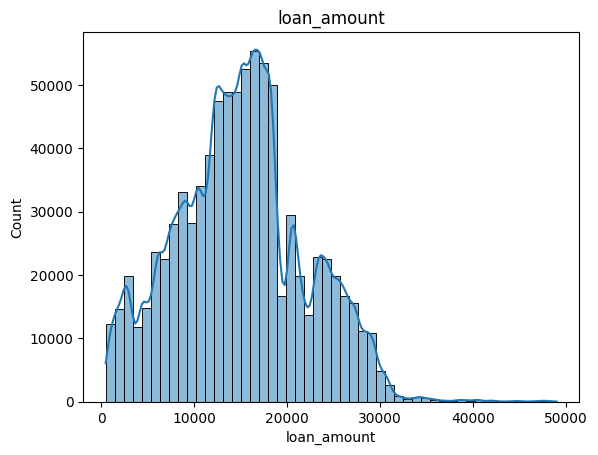

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


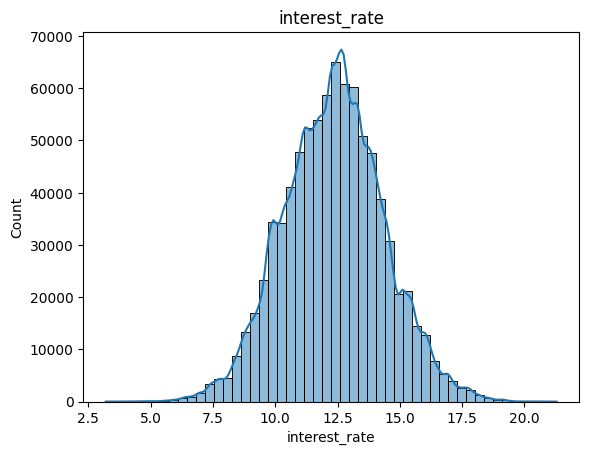

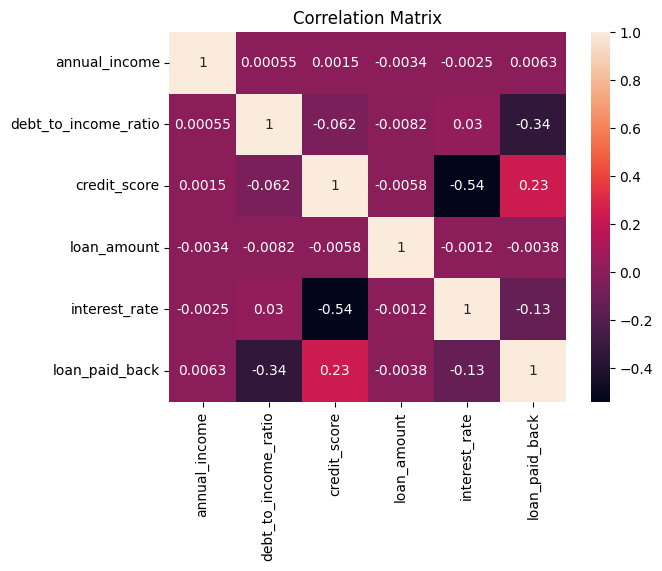

In [29]:
numeric_cols = ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']

# Summary statistics
df[numeric_cols].describe()

# Visualize distributions
for col in numeric_cols:
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(col)
    plt.show()

# Correlation with target
train_df = df[df['dataset']=='train']
corr_matrix = train_df[numeric_cols + ['loan_paid_back']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()


# 3.3 Remove irrelevant columns

In [14]:
df_proc = df.copy()
df_proc = df_proc.drop(columns=['id'])
df_proc.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,dataset
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,train
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,train
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,train
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,train
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,train


## 3.4 Filling missing values

In [15]:
numeric_cols = ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']

# Log-transform skewed columns
for col in ['annual_income','loan_amount']:
    df_proc[col] = np.log1p(df_proc[col])

# Summary statistics
df_proc[numeric_cols].describe()


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,848563.000000,848563.000000,848563.000000,848563.000000,848563.000000
mean,10.635817,0.120662,680.952514,9.462977,12.355139
std,0.560958,0.068576,55.484775,0.646047,2.011555
min,8.700086,0.011000,395.000000,6.216706,3.200000
25%,10.237843,0.072000,646.000000,9.237567,10.990000
50%,10.748360,0.096000,682.000000,9.615887,12.370000
75%,11.018709,0.156000,719.000000,9.844402,13.680000
max,12.882538,0.627000,849.000000,10.798778,21.290000


# 3.5 Enconding

In [16]:
# education_level ordinal
education_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3,
    "Other": 0
}
df_proc['education_level'] = df_proc['education_level'].map(education_map)

# grade_subgrade ordinal
grade_order = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'E': 1, 'F': 0}
def grade_to_ordinal(subgrade):
    letter = subgrade[0]
    number = int(subgrade[1])
    return grade_order[letter]*5 + (5 - number)

df_proc['grade_subgrade'] = df_proc['grade_subgrade'].apply(grade_to_ordinal)

df_proc[['education_level','grade_subgrade']].head()


,education_level,grade_subgrade
0,0,17
1,2,12
2,0,15
3,0,4
4,0,14


# One-hot encoding

In [17]:
nominal_cols = ['gender','marital_status','employment_status','loan_purpose']

# Merge rare categories
df_proc['gender'] = df_proc['gender'].replace({'Other':'Other'})
df_proc['marital_status'] = df_proc['marital_status'].replace({'Widowed':'Other'})
df_proc['employment_status'] = df_proc['employment_status'].replace({'Student':'Other','Retired':'Other'})
df_proc['loan_purpose'] = df_proc['loan_purpose'].replace({'Vacation':'Other','Other':'Other'})

# One-hot encoding
df_proc = pd.get_dummies(df_proc, columns=nominal_cols, drop_first=True)

df_proc.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level,grade_subgrade,loan_paid_back,dataset,gender_Male,...,marital_status_Single,employment_status_Other,employment_status_Self-employed,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other
0,10.287695,0.084,736,7.835745,13.67,0,17,1.0,train,False,...,True,False,True,False,False,False,False,False,False,True
1,10.003741,0.166,636,8.432528,12.92,2,12,0.0,train,True,...,False,False,False,False,False,True,False,False,False,False
2,10.811085,0.097,694,9.741330,9.76,0,15,1.0,train,True,...,True,False,False,False,False,True,False,False,False,False
3,10.754904,0.065,533,8.451797,16.10,0,4,1.0,train,False,...,True,False,False,False,False,True,False,False,False,False
4,10.146344,0.053,665,9.407996,10.21,0,14,1.0,train,True,...,False,False,False,False,False,False,False,False,False,True


# ========================================
# TOP FEATURE ENGINEERING FOR LOAN DEFAULT
# ========================================

In [18]:
# 1. Loan-To-Income Ratio (Super powerful)
df_proc["loan_to_income"] = df_proc["loan_amount"] / (df_proc["annual_income"] + 1e-6)

# 2. Debt × Loan Interaction (DTI impact)
df_proc["debt_income_interaction"] = df_proc["debt_to_income_ratio"] * df_proc["loan_amount"]

# 3. Credit / Debt Interaction (Credit risk indicator)
df_proc["credit_debt_ratio"] = df_proc["credit_score"] / (df_proc["debt_to_income_ratio"] + 1e-6)

# 4. Log-Credit Score (smooth nonlinear effect)
df_proc["credit_score_log"] = np.log1p(df_proc["credit_score"])

# 5. Income Binning (Tree-friendly)
df_proc["income_bin"] = pd.qcut(df_proc["annual_income"], q=10, duplicates="drop", labels=False)

# 6. DTI Binning
df_proc["dti_bin"] = pd.qcut(df_proc["debt_to_income_ratio"], q=10, duplicates="drop", labels=False)

# 7. Loan Purpose Indicators (Huge for this dataset)
if "loan_purpose" in df_proc.columns:
    df_proc["is_debt_consolidation"] = (df_proc["loan_purpose"] == "Debt Consolidation").astype(int)
    df_proc["is_credit_card"] = (df_proc["loan_purpose"] == "Credit Card").astype(int)

# 8. Grade Decomposition (Letter + Number)
if "grade_subgrade_str" in df_proc.columns:
    df_proc["grade_letter"] = df_proc["grade_subgrade_str"].str[0]
    df_proc["subgrade_num"] = df_proc["grade_subgrade_str"].str[1].astype(int)
    
    grade_map = {"A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1}
    df_proc["grade_letter"] = df_proc["grade_letter"].map(grade_map)

# 9. Loan/Credit Ratio
df_proc["loan_credit_ratio"] = df_proc["loan_amount"] / (df_proc["credit_score"] + 1e-6)

# 10. Risk Score (Hand-crafted — often boosts AUC)
df_proc["risk_score"] = df_proc["credit_score"] - df_proc["debt_to_income_ratio"] * 100 - df_proc["interest_rate"] * 20


## 4. Model Building
**Libraries Required**
# 4.1 Separate processed train/test sets

In [19]:
# Separate processed train/test sets
df_train_proc = df_proc[df_proc['dataset']=='train'].drop(columns=['dataset'])
df_test_proc = df_proc[df_proc['dataset']=='test'].drop(columns=['dataset','loan_paid_back'])

# Features and target
X_train = df_train_proc.drop(columns=['loan_paid_back'])
y_train = df_train_proc['loan_paid_back'].astype(int)

X_test = df_test_proc.copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (593994, 29)
y_train shape: (593994,)
X_test shape: (254569, 29)


# 4.2 Convert to NumPy arrays

In [20]:
# Convert to NumPy arrays
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values

# Align test columns
X_test_aligned = pd.DataFrame(X_test_np, columns=X_train.columns)
X_test_aligned = X_test_aligned.reindex(columns=X_train.columns, fill_value=0)
X_test_np = X_test_aligned.values

# 4.3 Train Model,Evaluate Model

In [ ]:

# =========================
# Supercharged Hybrid Stacking (6000 iterations, GPU-ready)
# =========================
import numpy as np
from sklearn.model_selection import KFold
from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb

# =========================
# Base Model Hyperparameters (GPU)
# =========================

cat_params = {
    'iterations': 6000,
    'learning_rate': 0.02,
    'depth': 8,
    'l2_leaf_reg': 7,
    'border_count': 254,
    'bagging_temperature': 0.8,
    'random_strength': 2,
    'one_hot_max_size': 10,
    'verbose': 0,
    'random_seed': 42,
    'task_type': 'GPU',
    'devices': '0:1'
}

lgb_params = {
    'n_estimators': 6000,
    'learning_rate': 0.02,
    'num_leaves': 63,
    'max_depth': 10,
    'min_child_samples': 15,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_alpha': 0.2,
    'reg_lambda': 0.2,
    'importance_type': 'gain',
    'random_state': 42,
    'n_jobs': -1,
    'device': 'gpu'
}

xgb_params = {
    'n_estimators': 6000,
    'learning_rate': 0.02,
    'max_depth': 8,
    'min_child_weight': 1,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'gamma': 0.2,
    'reg_alpha': 0.2,
    'reg_lambda': 1,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'gpu_hist'
}

meta_params = {
    'n_estimators': 3000,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 5,
    'min_child_samples': 10,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_alpha': 0.2,
    'reg_lambda': 0.2,
    'random_state': 42,
    'n_jobs': -1,
    'device': 'gpu'
}

# -------------------------
# Cell 7 — Out-of-Fold Stacking
# -------------------------
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_cat = np.zeros(len(X_train_np))
oof_lgb = np.zeros(len(X_train_np))
oof_xgb = np.zeros(len(X_train_np))

pred_cat_test = np.zeros(len(X_test_np))
pred_lgb_test = np.zeros(len(X_test_np))
pred_xgb_test = np.zeros(len(X_test_np))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_np), 1):
    print(f"Fold {fold}/{n_folds} starting...")
    X_tr, X_val = X_train_np[train_idx], X_train_np[val_idx]
    y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]

    # ---- CatBoost ----
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=300)
    oof_cat[val_idx] = cat.predict_proba(X_val)[:,1]
    pred_cat_test += cat.predict_proba(X_test_np)[:,1] / n_folds
    print("  CatBoost done.")

    # ---- LightGBM ----
    lgbm = lgb.LGBMClassifier(**lgb_params)
    # NEW API: use callbacks for early stopping
    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(300)]
    )
    oof_lgb[val_idx] = lgbm.predict_proba(X_val)[:,1]
    pred_lgb_test += lgbm.predict_proba(X_test_np)[:,1] / n_folds
    print("  LightGBM done.")

    # ---- XGBoost ----
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=300, verbose=False)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:,1]
    pred_xgb_test += xgb_model.predict_proba(X_test_np)[:,1] / n_folds
    print("  XGBoost done.")

# -------------------------
# Cell 8 — Meta-Model Training & Prediction
# -------------------------
X_meta_train = np.column_stack([oof_cat, oof_lgb, oof_xgb])
X_meta_test  = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])

meta_model = lgb.LGBMClassifier(**meta_params)
# use early stopping via callback on a small internal split if desired; here we train on full meta features
meta_model.fit(X_meta_train, y_train_np)
final_pred = meta_model.predict_proba(X_meta_test)[:,1]


# 5. Submission File

In [22]:
# Make sure final_pred matches df_test length
assert len(final_pred) == len(df_test), f"Length mismatch: final_pred {len(final_pred)} vs df_test {len(df_test)}"

# Create binary predictions (threshold 0.5)
df_test['loan_paid_back'] = (final_pred > 0.5).astype(int)  # change column name if needed

# Create submission DataFrame
submission = df_test[['id', 'loan_paid_back']].copy()  # adjust 'id' column name to match your dataset

# Save to CSV
submission.to_csv('hybrid_stacking_submission.csv', index=False)
print("Submission CSV saved as 'hybrid_stacking_submission.csv'")

Submission CSV saved as 'hybrid_stacking_submission.csv'


## 5. Model Accuracy_Score
**Predictions CV SCORE**

In [23]:
# -------------------------
# Cell 9 — CV Score Summary + Prediction Output
# -------------------------

from sklearn.metrics import roc_auc_score

# ---- 1. Compute CV Scores for Base Models ----
cv_cat = []
cv_lgb = []
cv_xgb = []

kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

for fold, (_, val_idx) in enumerate(kf.split(X_train_np), 1):
    auc_cat = roc_auc_score(y_train_np[val_idx], oof_cat[val_idx])
    auc_lgb = roc_auc_score(y_train_np[val_idx], oof_lgb[val_idx])
    auc_xgb = roc_auc_score(y_train_np[val_idx], oof_xgb[val_idx])

    cv_cat.append(auc_cat)
    cv_lgb.append(auc_lgb)
    cv_xgb.append(auc_xgb)

    print(f"Fold {fold} AUC — CatBoost: {auc_cat:.5f}, LightGBM: {auc_lgb:.5f}, XGBoost: {auc_xgb:.5f}")

print("\n===== MEAN CV SCORES =====")
print(f"CatBoost CV AUC:  {np.mean(cv_cat):.5f}")
print(f"LightGBM CV AUC:  {np.mean(cv_lgb):.5f}")
print(f"XGBoost CV AUC:   {np.mean(cv_xgb):.5f}")

# ---- 2. Meta-model CV (using OOF features) ----
meta_auc = roc_auc_score(y_train_np, meta_model.predict_proba(X_meta_train)[:,1])
print("\n===== META-MODEL SCORE =====")
print(f"Meta-Model (LGBM) AUC: {meta_auc:.5f}")

# ---- 3. Show some prediction values ----
print("\n===== SAMPLE FINAL PREDICTIONS =====")
print(final_pred[:20])   # first 20 predictions

# If you want to see full array:
# print(final_pred)


Fold 1 AUC — CatBoost: 0.91282, LightGBM: 0.91353, XGBoost: 0.91225
Fold 2 AUC — CatBoost: 0.91287, LightGBM: 0.91381, XGBoost: 0.91226
Fold 3 AUC — CatBoost: 0.91285, LightGBM: 0.91361, XGBoost: 0.91176
Fold 4 AUC — CatBoost: 0.91052, LightGBM: 0.91172, XGBoost: 0.90991
Fold 5 AUC — CatBoost: 0.91301, LightGBM: 0.91350, XGBoost: 0.91175

===== MEAN CV SCORES =====
CatBoost CV AUC:  0.91241
LightGBM CV AUC:  0.91323
XGBoost CV AUC:   0.91159

===== META-MODEL SCORE =====
Meta-Model (LGBM) AUC: 0.91975

===== SAMPLE FINAL PREDICTIONS =====
[0.93827696 0.97312556 0.40653882 0.94649864 0.95743097 0.98001567
 0.98491391 0.97306656 0.94316264 0.00127958 0.0680755  0.9955052
 0.63457854 0.03381828 0.97078617 0.73618563 0.99666751 0.7982336
 0.97768664 0.935917  ]


# 6. Submission File(Optional)

In [ ]:
print(len(df_test), X_test_np.shape)

df_test['loan_paid_back'] = (final_pred > 0.5).astype(int)  # or just use final_pred if probabilities needed

# Create submission DataFrame
submission = df_test[['id', 'loan_paid_back']].copy()  # assuming Titanic dataset; adjust column as needed

# Save to CSV
submission.to_csv('hybrid_stacking_submission.csv', index=False)
print("Submission CSV saved as 'hybrid_stacking_submission.csv'")

# Delete Submission File(If anything go wrong)

In [21]:
import os

file_path = '/kaggle/working/submission_binary.csv'

# Check if file exists, then delete
if os.path.exists(file_path):
    os.remove(file_path)
    print(f"File '{file_path}' has been deleted.")
else:
    print(f"File '{file_path}' does not exist.")


File '/kaggle/working/submission_binary.csv' has been deleted.
